In [1]:
import os
import numpy as np
from skimage import io, color, transform, feature
from joblib import load, dump
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Function to preprocess the image and extract HOG features
def preprocess_image(image_path):
    image = io.imread(image_path)  # Read the image
    image = transform.resize(image, (64, 64))  # Resize to 64x64
    
    # Check if the image has three channels (color) and convert to grayscale if necessary
    if image.ndim == 3:
        image = color.rgb2gray(image)
    
    # Extract HOG features
    hog_features = feature.hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    return hog_features


# Load the trained model
model_path = r"E:\gp_final\image\recogntion\ASL\svm\version_1\svm_asl_model.joblib"
model = load(model_path)

# Specify the path to the new training data (update this path to your ArASL dataset)
train_data_dir = r"C:\Users\Administrator\Desktop\archive (1)1\ArASL_Database_54K"

# Initialize lists to hold HOG features and labels
hog_features = []
labels = []

# Iterate through each folder in the training data directory
for folder in os.listdir(train_data_dir):
    folder_path = os.path.join(train_data_dir, folder)
    if os.path.isdir(folder_path):
        label = folder  # The folder name serves as the label
        for image_name in os.listdir(folder_path):
            image_path = os.path.join(folder_path, image_name)
            # Preprocess the image and extract HOG features
            features = preprocess_image(image_path)
            hog_features.append(features)
            labels.append(label)

# Convert lists to numpy arrays
X = np.array(hog_features)
y = np.array(labels)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.2.2 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
# Train the model on the new data
model.fit(X_train, y_train)

SVC(kernel='linear')

In [3]:
# Evaluate the model on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9490286771507863
Classification Report:
              precision    recall  f1-score   support

           أ       0.96      0.96      0.96       342
           ئ       0.96      0.97      0.97       351
          ال       0.98      0.97      0.97       276
           ب       0.93      0.94      0.94       385
           ة       0.92      0.94      0.93       367
           ت       0.93      0.95      0.94       380
           ث       0.94      0.94      0.94       347
           ج       0.91      0.92      0.91       298
           ح       0.95      0.95      0.95       300
           خ       0.95      0.96      0.96       306
           د       0.93      0.92      0.93       300
           ذ       0.94      0.96      0.95       325
           ر       0.95      0.94      0.95       346
           ز       0.94      0.94      0.94       278
           س       0.97      0.97      0.97       302
           ش       0.98      0.97      0.97       296
           ص       0.94      

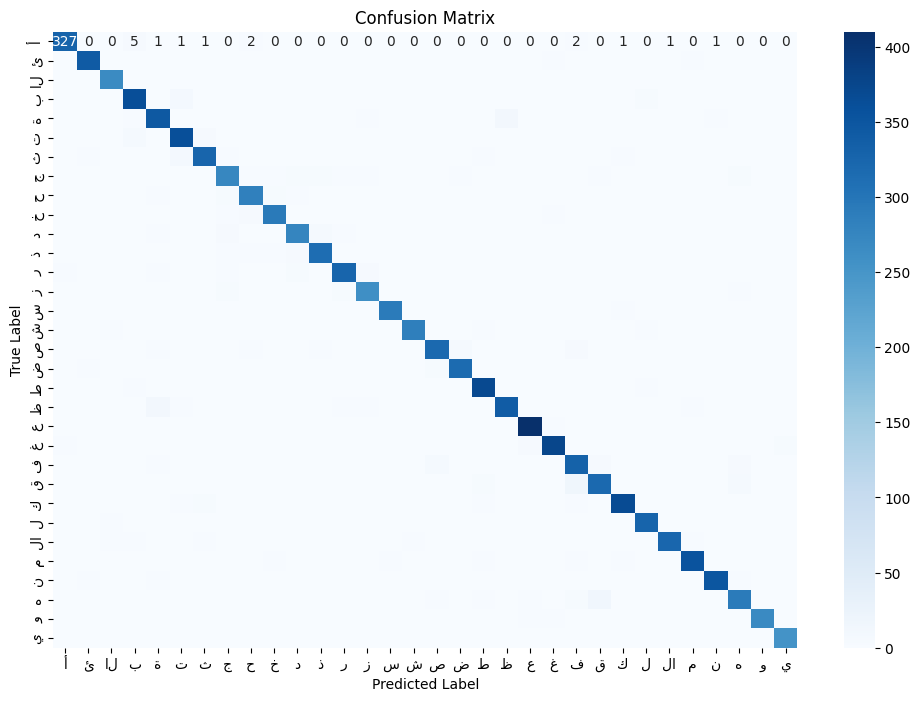

In [4]:
# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [5]:

import joblib  # Import joblib for model persistence# Save the trained model
model_filename = r"E:\gp_final\image\recogntion\ARSL\svm\svm_arsl_model1.joblib"
joblib.dump(model, model_filename)
print(f'Model saved to {model_filename}')

Model saved to E:\gp_final\image\recogntion\ARSL\svm\svm_arsl_model1.joblib


In [10]:
!pip install pillow


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import cv2
import numpy as np
from skimage import color, transform, feature
from joblib import load
import mediapipe as mp
from PIL import Image, ImageDraw, ImageFont

# Load the trained SVM model
model_path = r"E:\gp_final\image\recogntion\ARSL\svm\svm_arsl_model1.joblib"
model = load(model_path)

# Function to preprocess the image and extract HOG features
def preprocess_image(image):
    try:
        image = transform.resize(image, (64, 64))  # Resize to 64x64
        image = color.rgb2gray(image)  # Convert to grayscale
        hog_features = feature.hog(image, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        return hog_features
    except Exception as e:
        print(f"Error in preprocessing image: {e}")
        return None

# Function to add Arabic text to an OpenCV frame
def add_arabic_text(frame, text, position, font_path="amiri.ttf", font_size=32, color=(0, 255, 0)):
    try:
        # Convert OpenCV image (BGR) to PIL image (RGB)
        frame_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        draw = ImageDraw.Draw(frame_pil)

        # Load Arabic-supporting font
        font = ImageFont.truetype(font_path, font_size)

        # Add text to the image
        draw.text(position, text, font=font, fill=color)

        # Convert back to OpenCV image (BGR)
        frame = cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGB2BGR)
        return frame
    except Exception as e:
        print(f"Error in rendering Arabic text: {e}")
        return frame

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False,
                       max_num_hands=1,
                       min_detection_confidence=0.5,
                       min_tracking_confidence=0.5)

# Initialize the webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Path to the Arabic font file
font_path = r"C:\Users\Administrator\Desktop\Amiri\Amiri-Regular.ttf"  # Replace with the actual path to the font

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture frame. Exiting...")
            break

        # Convert the frame to RGB as MediaPipe expects RGB images
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Use MediaPipe to detect hands in the frame
        results = hands.process(frame_rgb)
        
        if results.multi_hand_landmarks:
            # A hand is detected, proceed with preprocessing and prediction
            hog_features = preprocess_image(frame_rgb)
            
            if hog_features is not None:
                # Reshape for the model (1 sample, number of features)
                hog_features = np.array(hog_features).reshape(1, -1)
                
                # Perform inference
                try:
                    predicted_letter = model.predict(hog_features)[0]  # Directly get the Arabic letter
                except Exception as e:
                    print(f"Error during prediction: {e}")
                    predicted_letter = "?"

                # Draw hand landmarks on the frame
                for hand_landmarks in results.multi_hand_landmarks:
                    mp.solutions.drawing_utils.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
                
                # Add the predicted letter (Arabic) to the frame
                frame = add_arabic_text(frame, f'Predicted Letter: {predicted_letter}', (10, 50), font_path)
            else:
                frame = add_arabic_text(frame, 'Error in preprocessing', (10, 50), font_path, color=(255, 0, 0))
        else:
            frame = add_arabic_text(frame, 'No hand detected', (10, 50), font_path, color=(255, 0, 0))
        
        # Display the resulting frame
        cv2.imshow('Real-Time Sign Language Recognition', frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    hands.close()


C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

...

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt